In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from ordered_set import OrderedSet

from StoneSoupID.stonesoupID.types.groundtruth import GroundTruthPath, GroundTruthState
from StoneSoupID.stonesoupID.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    LinearGaussianTimeInvariantTransitionModel
)
from StoneSoupID.stonesoupID.models.measurement.linear import LinearGaussian
from StoneSoupID.stonesoupID.types.detection import TrueDetection
from StoneSoupID.stonesoupID.types.state import GaussianState
from StoneSoupID.stonesoupID.predictor.kalman import KalmanPredictor
from StoneSoupID.stonesoupID.updater.kalman import KalmanUpdater
from StoneSoupID.stonesoupID.hypothesiser.probability import PDAHypothesiser
from StoneSoupID.stonesoupID.dataassociator.probability import JPDAwithLBP as JPDA
from StoneSoupID.stonesoupID.initiator.simple import MultiMeasurementInitiator
from StoneSoupID.stonesoupID.deleter.time import UpdateTimeDeleter
from StoneSoupID.stonesoupID.tracker.simple import MultiTargetTracker

# ---- Augmented Measurement Model for AR(1) Noise ----
class Augmented2DMeasurement(LinearGaussian):
    def function(self, state_vector, noise=False, **kwargs):
        # Accept both State objects and numpy arrays
        if hasattr(state_vector, 'state_vector'):
            s = np.asarray(state_vector.state_vector).flatten()
        else:
            s = np.asarray(state_vector).flatten()
        vec = np.array([
            s[0] + s[4],
            s[2] + s[5]
        ]).reshape(2, 1)
        if noise is True:
            vec += self.rvs()
        return vec

    def jacobian(self, state_vector, **kwargs):
        H = np.zeros((2, 6))
        H[0, 0] = 1  # x
        H[0, 4] = 1  # n_x
        H[1, 2] = 1  # y
        H[1, 5] = 1  # n_y
        return H

# ---- KF Experiment Function ----
def run_kf_experiment(seed, num_steps, rho, process_noise_var, sigma):
    np.random.seed(seed)
    init_states = [
        [0, 1, 0, 1, 0, 0],
        [20, -1, 10, -1, 0, 0]
    ]
    ar1_model = LinearGaussianTimeInvariantTransitionModel(
        transition_matrix=np.array([[rho]]),
        covariance_matrix=np.array([[sigma**2]])
    )
    transition_model = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(np.sqrt(process_noise_var)),
        ConstantVelocity(np.sqrt(process_noise_var)),
        ar1_model, ar1_model
    ])

    measurement_model = Augmented2DMeasurement(
        ndim_state=6,
        mapping=(0, 2),
        noise_covar=np.zeros((2, 2))
    )
    dt = 0.05
    timesteps = [datetime.now() + timedelta(seconds=k*dt) for k in range(num_steps + 1)]
    truths = OrderedSet()
    truth_paths = []
    for state in init_states:
        truth = GroundTruthPath([GroundTruthState(state, timestamp=timesteps[0])])
        for k in range(1, num_steps + 1):
            next_state = transition_model.function(truth[k-1], noise=True, time_interval=timedelta(seconds=dt))
            truth.append(GroundTruthState(next_state, timestamp=timesteps[k]))
        truths.add(truth)
        truth_paths.append(truth)
    all_measurements = []
    for k in range(num_steps + 1):
        measurement_set = set()
        for idx, truth in enumerate(truth_paths):
            s = truth[k].state_vector.flatten()
            meas_vec = np.array([s[0] + s[4], s[2] + s[5]])
            measurement_set.add(TrueDetection(
                state_vector=meas_vec.reshape(-1, 1),
                groundtruth_path=truth,
                timestamp=timesteps[k],
                measurement_model=measurement_model
            ))
        all_measurements.append(measurement_set)

    predictor = KalmanPredictor(transition_model)
    updater = KalmanUpdater(measurement_model)
    hypothesiser = PDAHypothesiser(
        predictor=predictor,
        updater=updater,
        clutter_spatial_density=1e-12,
        prob_detect=1.0,
        prob_gate=0.999
    )
    data_associator = JPDA(hypothesiser=hypothesiser)
    prior_cov = np.diag([100, 10, 100, 10, 25, 25])
    prior_state = GaussianState(np.array(init_states[0]).reshape(-1, 1), prior_cov, timestamp=timesteps[0])
    deleter = UpdateTimeDeleter(time_since_update=timedelta(seconds=10))
    initiator = MultiMeasurementInitiator(
        prior_state=prior_state,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        measurement_model=measurement_model,
        min_points=1
    )

    detector = iter(list(zip(timesteps, all_measurements)))
    tracker = MultiTargetTracker(
        initiator=initiator,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        detector=detector
    )

    tracks = set()
    for time, curr_tracks in tracker:
        tracks |= curr_tracks
    tracks = {track for track in tracks if len(track) > 3}
    tracks = list(tracks)

    truth_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in truth]) for truth in truth_paths]
    track_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in track]) for track in tracks]

    rmse_time = []
    for t in range(num_steps + 1):
        errors = []
        for truth in truth_arrays:
            min_err = None
            for track in track_arrays:
                if t < track.shape[0]:
                    err = np.linalg.norm(track[t] - truth[t])
                    if (min_err is None) or (err < min_err):
                        min_err = err
            if min_err is not None:
                errors.append(min_err ** 2)
        if errors:
            rmse_t = np.sqrt(np.mean(errors))
            rmse_time.append(rmse_t)
        else:
            rmse_time.append(np.nan)
    overall_rmse = np.nanmean(rmse_time)
    return np.array(rmse_time), overall_rmse

# --- Run 10 seeds and average ---
num_seeds = 10
seeds = np.random.randint(0, 1e9, num_seeds)
num_steps = 500
rho = 0.95
sigma = 3.0
process_noise_var = 0.02
all_rmse = []
overall_rmse_list = []
for seed in range(num_seeds):
    rmse_time, overall_rmse = run_kf_experiment(seed, num_steps, rho, process_noise_var, sigma)
    all_rmse.append(rmse_time)
    overall_rmse_list.append(overall_rmse)

all_rmse = np.vstack(all_rmse)
mean_rmse = np.nanmean(all_rmse, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(mean_rmse, label="Mean RMSE (10 seeds)")
plt.xlabel("Time Step")
plt.ylabel("RMSE")
plt.title("Averaged RMSE vs Time over 10 seeds")
plt.grid(linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average of Mean Overall RMSEs: {np.mean(overall_rmse_list):.3f}")
print(mean_rmse)
"""
def get_rho_plot(seed, num_steps, rho, process_noise_var, sigma):
    rho_values = np.linspace(0.90, 0.999, 16)
    mean_overall_rmses = []
    for rho in rho_values:
        all_rmse = []
        overall_rmse_list = []
        np.random.seed(12345)
        seeds = np.random.randint(0, 1e9, num_seeds)
        for seed in seeds:
            rmse_time, overall_rmse = run_kf_experiment(seed, num_steps, rho, process_noise_var, sigma)
            all_rmse.append(rmse_time)
            overall_rmse_list.append(overall_rmse)
        mean_overall_rmses.append(np.mean(overall_rmse_list))

    plt.figure()
    plt.plot(rho_values, mean_overall_rmses, marker="o")
    plt.xlabel(r"AR(1) $\rho$")
    plt.ylabel("Mean Overall RMSE")
    plt.title("RMSE vs AR(1) Persistence ($\\rho$)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return mean_overall_rmses

_ = get_rho_plot(seed, num_steps, rho, process_noise_var, sigma)
"""

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from ordered_set import OrderedSet

from StoneSoupID.stonesoupID.types.groundtruth import GroundTruthPath, GroundTruthState
from StoneSoupID.stonesoupID.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    LinearGaussianTimeInvariantTransitionModel
)
from StoneSoupID.stonesoupID.models.measurement.linear import LinearGaussian
from StoneSoupID.stonesoupID.types.detection import TrueDetection
from StoneSoupID.stonesoupID.types.state import GaussianState
from StoneSoupID.stonesoupID.predictor.kalman import KalmanPredictor
from StoneSoupID.stonesoupID.updater.kalman import KalmanUpdater
from StoneSoupID.stonesoupID.hypothesiser.probability import PDAHypothesiser
from StoneSoupID.stonesoupID.dataassociator.probability import JPDAwithLBP as JPDA
from StoneSoupID.stonesoupID.initiator.simple import MultiMeasurementInitiator
from StoneSoupID.stonesoupID.deleter.time import UpdateTimeDeleter
from StoneSoupID.stonesoupID.tracker.simple import MultiTargetTracker

# ---- Augmented Measurement Model for AR(1) Noise ----
class Augmented2DMeasurement(LinearGaussian):
    def function(self, state_vector, noise=False, **kwargs):
        # Accept both State objects and numpy arrays
        if hasattr(state_vector, 'state_vector'):
            s = np.asarray(state_vector.state_vector).flatten()
        else:
            s = np.asarray(state_vector).flatten()
        vec = np.array([
            s[0] + s[4],
            s[2] + s[5]
        ]).reshape(2, 1)
        if noise is True:
            vec += self.rvs()
        return vec

    def jacobian(self, state_vector, **kwargs):
        H = np.zeros((2, 6))
        H[0, 0] = 1  # x
        H[0, 4] = 1  # n_x
        H[1, 2] = 1  # y
        H[1, 5] = 1  # n_y
        return H

def run_kf_experiment_mismatch(seed, num_steps,
                               rho_true, sigma_true,      # Used for data generation
                               rho_filter, sigma_filter,  # Used for filtering
                               process_noise_var):
    np.random.seed(seed)
    init_states = [
        [0, 1, 0, 1, 0, 0],
        [20, -1, 10, -1, 0, 0]
    ]
    # 1. Truth uses "true" parameters
    ar1_model_truth = LinearGaussianTimeInvariantTransitionModel(
        transition_matrix=np.array([[rho_true]]),
        covariance_matrix=np.array([[sigma_true**2]])
    )
    transition_model_truth = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(np.sqrt(process_noise_var)),
        ConstantVelocity(np.sqrt(process_noise_var)),
        ar1_model_truth, ar1_model_truth
    ])
    # 2. Filter uses "mismatched" parameters
    ar1_model_filter = LinearGaussianTimeInvariantTransitionModel(
        transition_matrix=np.array([[rho_filter]]),
        covariance_matrix=np.array([[sigma_filter**2]])
    )
    transition_model_filter = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(np.sqrt(process_noise_var)),
        ConstantVelocity(np.sqrt(process_noise_var)),
        ar1_model_filter, ar1_model_filter
    ])

    measurement_model = Augmented2DMeasurement(
        ndim_state=6,
        mapping=(0, 2),
        noise_covar=np.zeros((2, 2))
    )
    dt = 0.05
    timesteps = [datetime.now() + timedelta(seconds=k*dt) for k in range(num_steps + 1)]
    # --- Generate truth and measurements with TRUE model ---
    truths = OrderedSet()
    truth_paths = []
    for state in init_states:
        truth = GroundTruthPath([GroundTruthState(state, timestamp=timesteps[0])])
        for k in range(1, num_steps + 1):
            next_state = transition_model_truth.function(truth[k-1], noise=True, time_interval=timedelta(seconds=dt))
            truth.append(GroundTruthState(next_state, timestamp=timesteps[k]))
        truths.add(truth)
        truth_paths.append(truth)
    all_measurements = []
    for k in range(num_steps + 1):
        measurement_set = set()
        for idx, truth in enumerate(truth_paths):
            s = truth[k].state_vector.flatten()
            meas_vec = np.array([s[0] + s[4], s[2] + s[5]])
            measurement_set.add(TrueDetection(
                state_vector=meas_vec.reshape(-1, 1),
                groundtruth_path=truth,
                timestamp=timesteps[k],
                measurement_model=measurement_model
            ))
        all_measurements.append(measurement_set)

    # --- Filtering using MISMATCHED model ---
    predictor = KalmanPredictor(transition_model_filter)
    updater = KalmanUpdater(measurement_model)
    hypothesiser = PDAHypothesiser(
        predictor=predictor,
        updater=updater,
        clutter_spatial_density=1e-12,
        prob_detect=1.0,
        prob_gate=0.999
    )
    data_associator = JPDA(hypothesiser=hypothesiser)
    prior_cov = np.diag([100, 10, 100, 10, 25, 25])
    prior_state = GaussianState(np.array(init_states[0]).reshape(-1, 1), prior_cov, timestamp=timesteps[0])
    deleter = UpdateTimeDeleter(time_since_update=timedelta(seconds=10))
    initiator = MultiMeasurementInitiator(
        prior_state=prior_state,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        measurement_model=measurement_model,
        min_points=1
    )

    detector = iter(list(zip(timesteps, all_measurements)))
    tracker = MultiTargetTracker(
        initiator=initiator,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        detector=detector
    )

    tracks = set()
    for time, curr_tracks in tracker:
        tracks |= curr_tracks
    tracks = {track for track in tracks if len(track) > 3}
    tracks = list(tracks)

    truth_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in truth]) for truth in truth_paths]
    track_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in track]) for track in tracks]

    rmse_time = []
    for t in range(num_steps + 1):
        errors = []
        for truth in truth_arrays:
            min_err = None
            for track in track_arrays:
                if t < track.shape[0]:
                    err = np.linalg.norm(track[t] - truth[t])
                    if (min_err is None) or (err < min_err):
                        min_err = err
            if min_err is not None:
                errors.append(min_err ** 2)
        if errors:
            rmse_t = np.sqrt(np.mean(errors))
            rmse_time.append(rmse_t)
        else:
            rmse_time.append(np.nan)
    overall_rmse = np.nanmean(rmse_time)
    return np.array(rmse_time), overall_rmse

num_seeds = 10
num_steps = 500

# "Truth" parameters (used in data generation)
rho_true = 0.95
sigma_true = 1.5

# "Filter" parameters (used in the filter model -- mismatch here!)
rho_filter = 0.90
sigma_filter = 0.5

process_noise_var = 0.02

all_rmse = []
overall_rmse_list = []
for seed in range(num_seeds):
    rmse_time, overall_rmse = run_kf_experiment_mismatch(
        seed, num_steps, rho_true, sigma_true, rho_filter, sigma_filter, process_noise_var)
    all_rmse.append(rmse_time)
    overall_rmse_list.append(overall_rmse)

all_rmse = np.vstack(all_rmse)
mean_rmse = np.nanmean(all_rmse, axis=0)

"""
plt.figure(figsize=(8, 4))
plt.plot(mean_rmse, label="Mean RMSE (mismatched params)")
plt.xlabel("Time Step")
plt.ylabel("RMSE")
plt.title("Averaged RMSE with Parameter Mismatch")
plt.grid(linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()
"""

print(f"Average of Mean Overall RMSEs: {np.mean(overall_rmse_list):.3f}")
print(mean_rmse)


/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:307: RuntimeWarning: divide by zero encountered in divide
  mu = likelihood_matrix[:, 1:] / s
/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:314: RuntimeWarning: invalid value encountered in subtract
  nu = 1 / (1 + np.sum(mu, axis=0, keepdims=True) - mu)
/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:317: RuntimeWarning: divide by zero encountered in log10
  d = np.max(np.abs(np.log10(nu / nu_tilde)))


Average of Mean Overall RMSEs: 7.265
[ 0.          0.09798307  0.18153487  0.27262403  0.32096993  0.43603146
  0.48799803  0.59050688  0.64476264  0.67202904  0.73334247  0.79582316
  0.79696844  0.80856293  0.78887864  0.8184175   0.83418611  0.83920393
  0.85291333  0.82314788  0.7744213   0.75784597  0.72339055  0.71561307
  0.70569238  0.7154592   0.8244159   0.90636565  0.95164577  0.97492336
  0.99204161  0.98833445  0.98538698  1.0519001   1.13122891  1.1191069
  1.10245907  1.11159993  1.13652666  1.18991931  1.21257747  1.20511139
  1.21359738  1.24153453  1.25180902  1.25701885  1.26014894  1.22471406
  1.16351566  1.1596187   1.23989742  1.33998803  1.42659799  1.48056261
  1.50089088  1.41677808  1.37064273  1.30885355  1.28118946  1.24498387
  1.20106813  1.15445136  1.16152926  1.16732666  1.23777111  1.30625679
  1.30470834  1.27751757  1.24952073  1.23522159  1.23603042  1.23105041
  1.23779256  1.25336815  1.38118435  1.41471938  1.44711285  1.46864207
  1.48271717  1

/var/folders/wk/r_3dm28j0wx2y0rl5hyq6bzc0000gn/T/ipykernel_26637/2935612133.py:191: RuntimeWarning: Mean of empty slice
  mean_rmse = np.nanmean(all_rmse, axis=0)


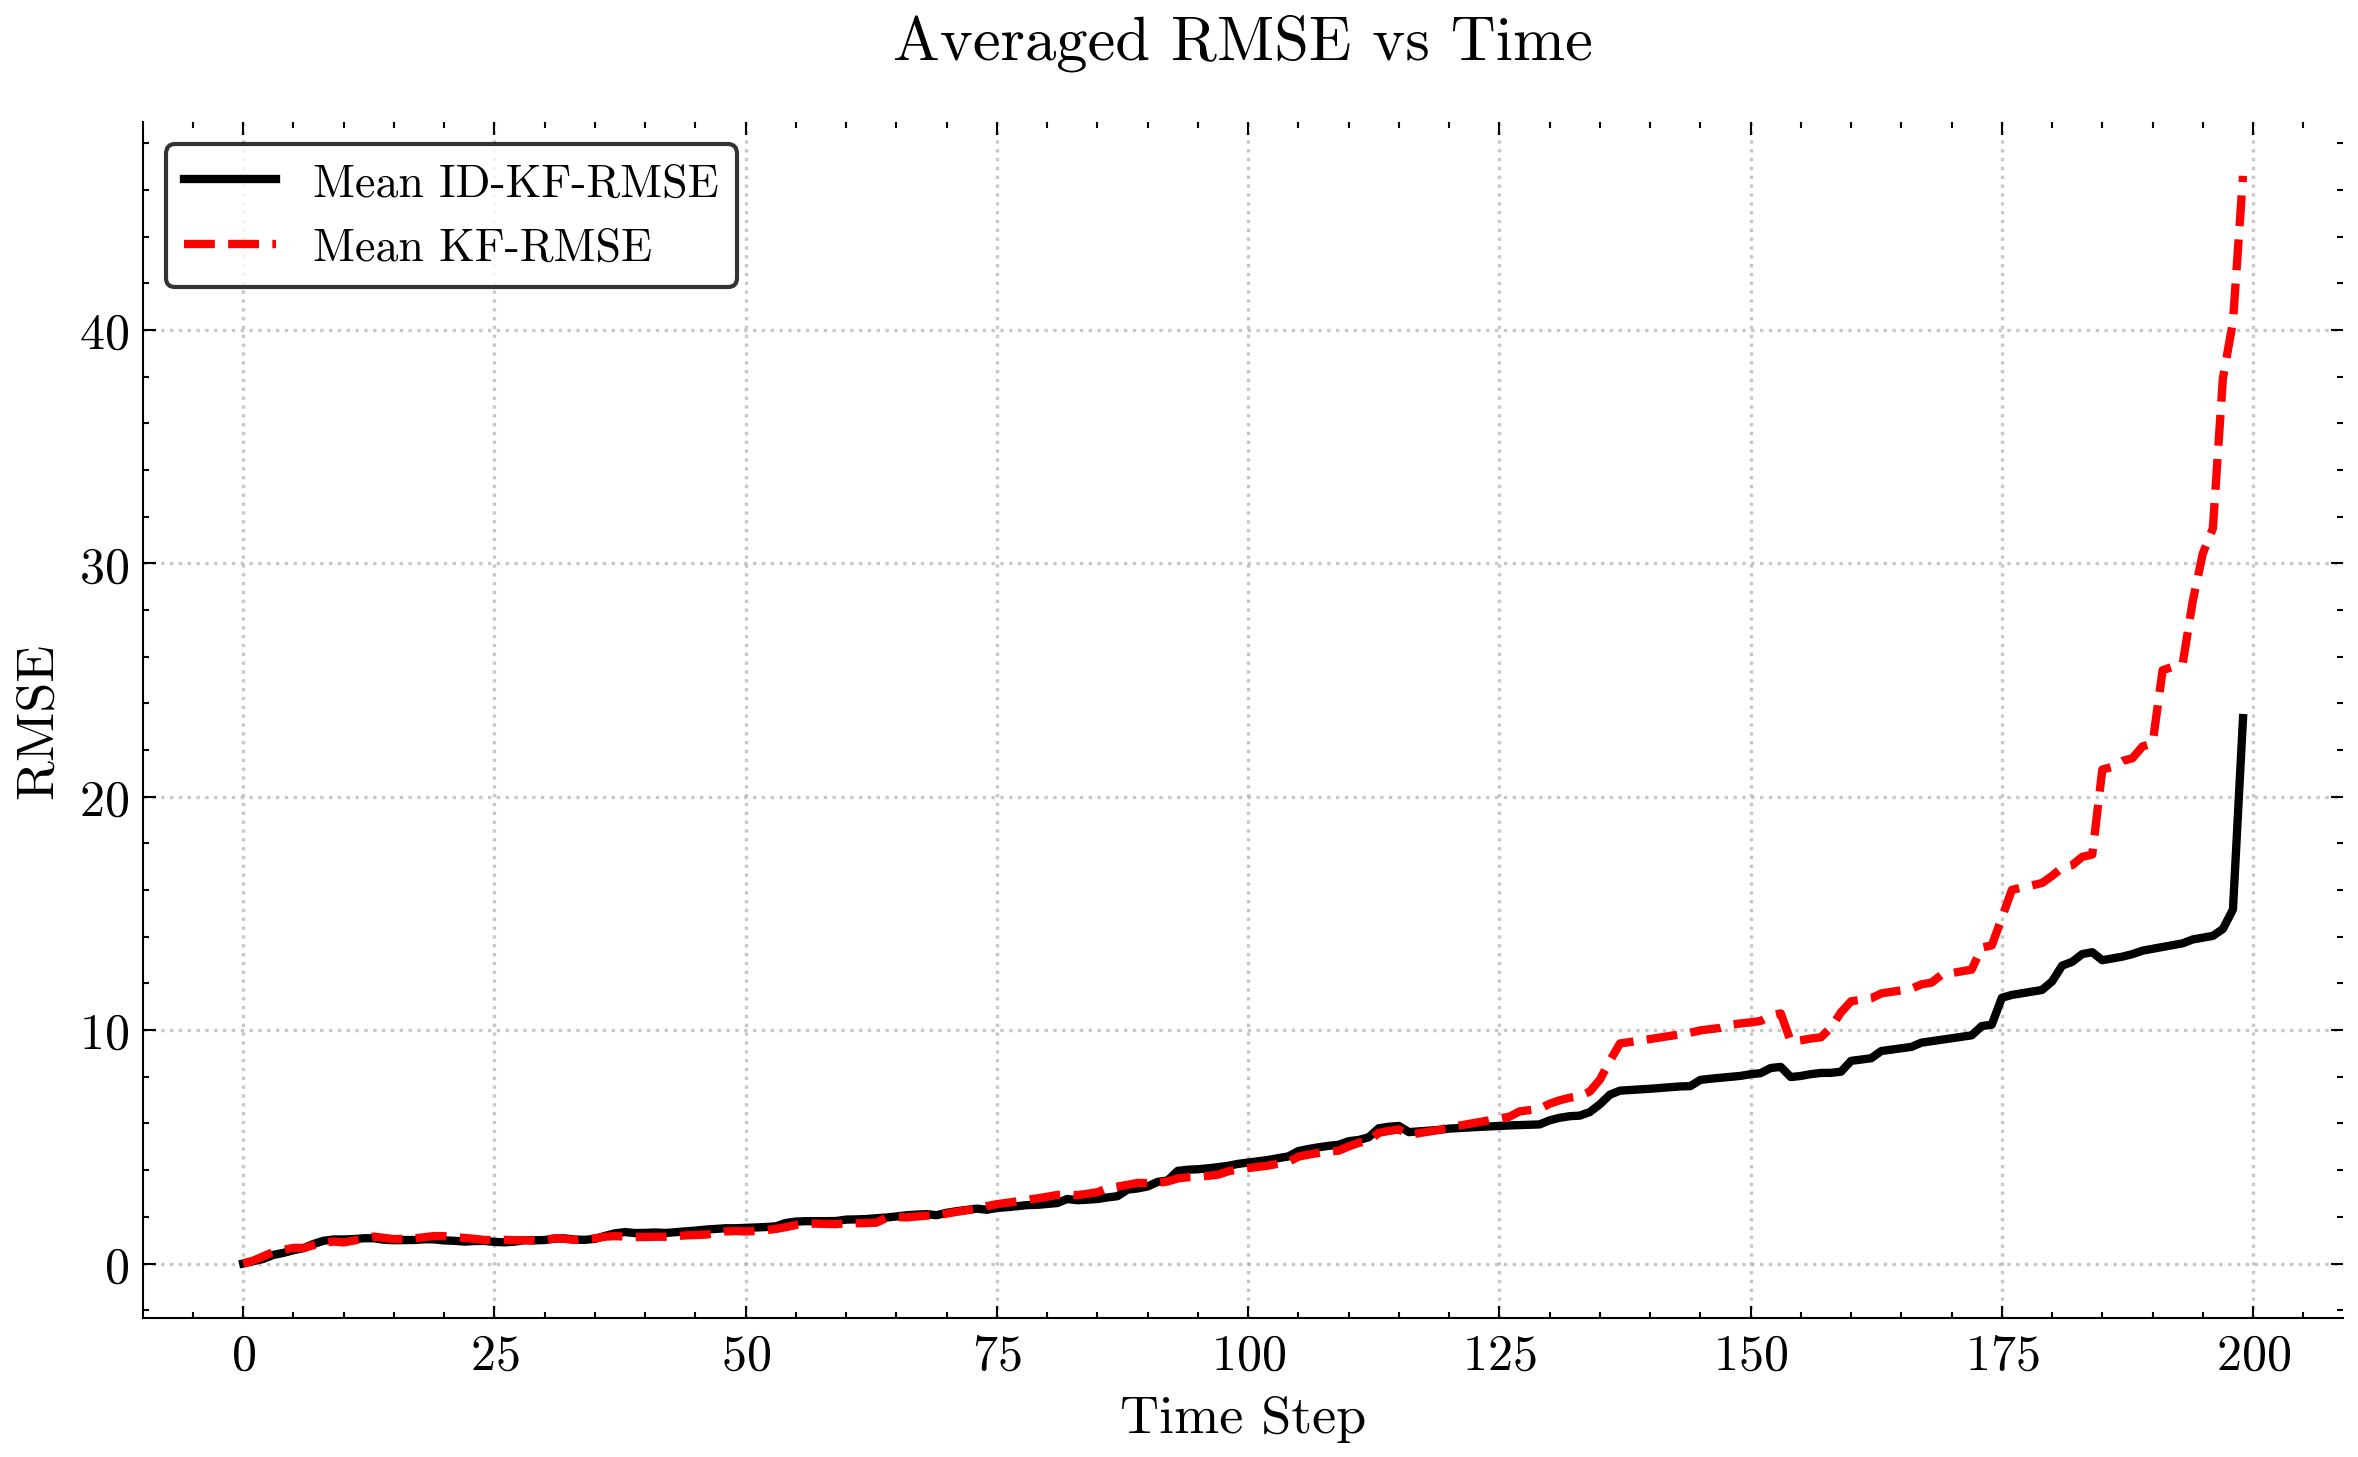

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'ieee', 'no-latex'])

# Data arrays (from your input)
mean_rmse_id = np.array([
    0., 0.10030837, 0.19773048, 0.36877441, 0.45507743, 0.56998847,
    0.65735703, 0.83731771, 0.97389975, 1.02967839, 1.02956408, 1.04657417,
    1.08224617, 1.08245792, 1.01771162, 0.99868177, 1.00572114, 1.00633228,
    1.03958249, 1.03534598, 0.98976926, 0.97334527, 0.9384283, 0.96226364,
    0.96790668, 0.9269063, 0.90707222, 0.93637079, 1.00094201, 0.99489838,
    1.00603088, 1.06654022, 1.07695609, 1.02410495, 1.0142872, 1.05683013,
    1.1820507, 1.29386189, 1.34661053, 1.30417041, 1.31239921, 1.32879786,
    1.30756595, 1.3420364, 1.37237826, 1.41008201, 1.45244683, 1.48130406,
    1.51033787, 1.51009119, 1.52813728, 1.54696859, 1.56217315, 1.59250691,
    1.7368101, 1.7964083, 1.8134142, 1.81190755, 1.81470987, 1.82135075,
    1.88181081, 1.890892, 1.90528562, 1.93782862, 1.9711854, 2.01545992,
    2.06782291, 2.09479535, 2.11362241, 2.07017343, 2.1732819, 2.24097832,
    2.29681748, 2.35077852, 2.30352077, 2.38047082, 2.41391271, 2.45521123,
    2.50210441, 2.5127028, 2.55240977, 2.5909075, 2.76446668, 2.71191766,
    2.73335647, 2.76466189, 2.83177944, 2.88504396, 3.16635434, 3.21591519,
    3.30136644, 3.4982856, 3.56025973, 3.97051144, 4.01905406, 4.03843285,
    4.07988631, 4.12825117, 4.18372151, 4.26938751, 4.32721657, 4.38246317,
    4.43691239, 4.5158229, 4.58787924, 4.81856808, 4.90645617, 4.9800108,
    5.04198278, 5.08665738, 5.24084215, 5.29307492, 5.41013502, 5.79618275,
    5.85892718, 5.89417868, 5.63044222, 5.66111056, 5.69447472, 5.72506809,
    5.77997295, 5.80458283, 5.83067445, 5.85447994, 5.87333211, 5.89355549,
    5.91635255, 5.92949237, 5.94351088, 5.95956739, 6.13450745, 6.24438328,
    6.31207705, 6.33632368, 6.49009401, 6.82130343, 7.23430996, 7.40722274,
    7.43270485, 7.4593839, 7.48827026, 7.52208959, 7.55335716, 7.58814875,
    7.60007317, 7.86793375, 7.91739399, 7.95690141, 7.99768705, 8.03960869,
    8.11234819, 8.15709661, 8.37778438, 8.42512053, 7.99032242, 8.03735647,
    8.11524053, 8.16570122, 8.16978096, 8.22025709, 8.68377858, 8.74038714,
    8.79575209, 9.10417631, 9.16504841, 9.22557836, 9.28316007, 9.46388502,
    9.52476728, 9.58709685, 9.65087516, 9.71631572, 9.7783894, 10.17312503,
    10.23525249, 11.38676674, 11.50991686, 11.57898483, 11.6489108, 11.72134637,
    12.08679763, 12.76493699, 12.92669165, 13.25934366, 13.33955866, 12.99702375,
    13.07307984, 13.14911098, 13.25798069, 13.4060561, 13.48359875, 13.5617315,
    13.64096427, 13.72097692, 13.88596807, 13.96221208, 14.03925294, 14.33661397,
    15.17056626, 23.37039648
])


mean_rmse = np.array([
    0., 0.12240372, 0.30887679, 0.49620868, 0.58029591, 0.6699887,
    0.66843033, 0.7842246, 0.89121372, 0.94242931, 0.90491446, 0.98147262,
    1.07347765, 1.1523695, 1.09678411, 1.04528115, 1.05474467, 1.07591302,
    1.12405797, 1.17640985, 1.1716033, 1.13819287, 1.09645312, 1.05847386,
    1.00777438, 1.00696414, 1.0160707, 1.00031773, 0.99816832, 0.97683924,
    0.99856229, 1.08162037, 1.05599483, 1.01279888, 1.03445809, 1.079304,
    1.1480244, 1.17306866, 1.15472689, 1.13253528, 1.13614926, 1.14524921,
    1.14607536, 1.16871028, 1.2042909, 1.21798766, 1.23660338, 1.29397645,
    1.37360972, 1.39370186, 1.37446993, 1.39283003, 1.42822036, 1.48168555,
    1.55750932, 1.64887032, 1.69532901, 1.70870361, 1.6953522, 1.68832642,
    1.72068683, 1.72759718, 1.73145261, 1.74920917, 1.95176711, 1.99193439,
    1.97501855, 2.01500073, 2.04874502, 2.04849382, 2.13891337, 2.21384332,
    2.28183427, 2.34664875, 2.45973018, 2.54390067, 2.60074201, 2.66408291,
    2.72879362, 2.78943505, 2.86024882, 2.9365186, 2.96886956, 2.93037827,
    2.98904167, 3.05566028, 3.22600165, 3.2964067, 3.3722838, 3.45442087,
    3.4430911, 3.45328411, 3.51510003, 3.64581491, 3.69405245, 3.71347188,
    3.75532942, 3.80451107, 3.94846353, 4.03233059, 4.08887104, 4.14313762,
    4.19717626, 4.27599312, 4.34777287, 4.57779463, 4.66521782, 4.73887329,
    4.80106501, 4.83242882, 5.01402467, 5.17079184, 5.24058065, 5.59795229,
    5.68123309, 5.74548961, 5.51687449, 5.58356183, 5.65329308, 5.72501211,
    5.83221601, 5.90926303, 5.98815301, 6.06599993, 6.13868004, 6.21304796,
    6.28964692, 6.51637562, 6.5734097, 6.63009615, 6.84443365, 6.99359091,
    7.10384182, 7.17126615, 7.36836864, 7.87452895, 8.68208883, 9.42850077,
    9.49052007, 9.55312886, 9.61739678, 9.68679866, 9.75293307, 9.82155137,
    9.88936893, 9.9891063, 10.04356776, 10.09796206, 10.22984793, 10.28739844,
    10.33386392, 10.39155283, 10.6252412, 10.71893172, 9.50946583, 9.56351107,
    9.64112084, 9.69479036, 10.109245, 10.76555231, 11.23744474, 11.30137154,
    11.36499076, 11.5733542, 11.63944428, 11.70575321, 11.77345925, 11.96411228,
    12.0344182, 12.36907224, 12.44351778, 12.51916795, 12.59593936, 13.5402728,
    13.63210576, 14.81038046, 16.01030244, 16.10718682, 16.2045684, 16.30337943,
    16.61001758, 16.96769698, 17.06894496, 17.42430359, 17.52563951, 21.16632601,
    21.28270796, 21.53257319, 21.65281352, 22.15875194, 22.28165765, 25.4231382,
    25.56707945, 25.71229555, 28.38856814, 30.42488778, 31.49604051, 37.94114114,
    40.35304224, 46.6054659
])

time_steps = np.arange(len(mean_rmse_id))

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

ax.plot(time_steps, mean_rmse_id, label="Mean ID-KF-RMSE", color='C0', linewidth=2)
ax.plot(time_steps, mean_rmse, label="Mean KF-RMSE", color='C1', linewidth=2, linestyle='--')

ax.set_xlabel("Time Step", fontsize=13, fontweight='bold')
ax.set_ylabel("RMSE", fontsize=13, fontweight='bold')
ax.set_title("Averaged RMSE vs Time", fontsize=15, fontweight='bold', pad=15)
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.7)
ax.legend(fontsize=11, frameon=True, loc='upper left', edgecolor='black', facecolor='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()
